In [2]:
from morbidity_analysis_module import morb_config
from cessation_lag_module import *
import pandas as pd

loaded defined RR values
Successfully loaded Cessation Lag functions


In [3]:
import cessation_lag_module as clm
try:
    _pick_morbidity_multiplier = clm._pick_morbidity_multiplier
except AttributeError:
    def _pick_morbidity_multiplier(health_outcome, pol, year, disease=None, cfg=None, default=1.0):
        try:
            return clm.pick_morbidity_multiplier(
                health_outcome=health_outcome,
                pol=pol,
                year=year,
                disease=disease,
                cfg=cfg,
                default=default,
            )
        except AttributeError:
            return default

In [3]:
# -------------------------
# Config
# -------------------------
scenarios = ["s1","s2", "s3","s4"]
pollutant_labels = {
    "ug_PM25_RH50": "PM2.5",
    "ug_NO2": "NO2",
}
years = ["2030", "2050"]
VSLY_BY_YEAR = {"2019": 135000, "2030": 152000, "2050": 192000}

DISEASE_TO_HEALTH_OUTCOME = {
    "Hypertension": "Hypertension (18+)",
    "Lung Cancer": "Lung Cancer (35+)",
    "Asthma in children": "Asthma (0–17)",
    "Asthma in adult": "Asthma (18–39)",
    "COPD": "COPD (40+)",
    "ALRI in children": "ALRI (0–12) per episode",
    "Stroke": "Stroke (35+)",
    "IHD events": "Myocardial Infarction (30+)",
    "Diabetes T2": "Type 2 Diabetes (45+)",
}

LAG_SCENARIOS = [
    ("no_lag", False),
    ("cessation_lag", True),
]

# -------------------------
# Main loop (now outputs per disease!)
# -------------------------
summary_data = []

for sc in scenarios:
    for pol in pollutant_labels.keys():
        for annee in years:
            base_path = os.path.join("data", "2-output-data", sc, pol, annee)
            morb_file = os.path.join(base_path, "morbidity_results.csv")
            if not os.path.exists(morb_file):
                continue
            vsly = float(VSLY_BY_YEAR.get(str(annee), VSLY_BY_YEAR["2019"]))
            results_df = pd.read_csv(morb_file)

            # Sensitivity 1 (mortality + YLL only)
            mort_file = os.path.join(base_path, "mortality_chimere_mc_senstivity.csv")
            mort_s1_c = mort_s1_l = mort_s1_u = 0.0
            yll_s1_c = yll_s1_l = yll_s1_u = 0.0
            if os.path.exists(mort_file):
                mort_df = pd.read_csv(mort_file)
                mort_s1_c = safe_sum(mort_df, find_col(mort_df, "mortpol_age"))
                mort_s1_l = safe_sum(mort_df, find_col(mort_df, "mortpol_LCI"))
                mort_s1_u = safe_sum(mort_df, find_col(mort_df, "mortpol_UCI"))
                yll_s1_c = safe_sum(mort_df, find_col(mort_df, "YLG"))
                yll_s1_l = safe_sum(mort_df, find_col(mort_df, "YLG_LCI"))
                yll_s1_u = safe_sum(mort_df, find_col(mort_df, "YLG_UCI"))

            # Main analysis (MC sensitivity file)
            mort_main_file = os.path.join(base_path, "mortality_chimere.csv")
            mort_main_c = mort_main_l = mort_main_u = 0.0
            yll_main_c = yll_main_l = yll_main_u = 0.0
            if os.path.exists(mort_main_file):
                mort_main_df = pd.read_csv(mort_main_file)
                mort_main_c = safe_sum(mort_main_df, find_col(mort_main_df, "mortpol_age"))
                mort_main_l = safe_sum(mort_main_df, find_col(mort_main_df, "mortpol_LCI"))
                mort_main_u = safe_sum(mort_main_df, find_col(mort_main_df, "mortpol_UCI"))
                yll_main_c = safe_sum(mort_main_df, find_col(mort_main_df, "YLG"))
                yll_main_l = safe_sum(mort_main_df, find_col(mort_main_df, "YLG_LCI"))
                yll_main_u = safe_sum(mort_main_df, find_col(mort_main_df, "YLG_UCI"))

            # Sensitivity 2 (population sensitivity)
            mort_sens2_file = os.path.join(base_path, "mortality_chimere_mc_senstivity_pop.csv")
            mort_s2_c = mort_s2_l = mort_s2_u = 0.0
            yll_s2_c = yll_s2_l = yll_s2_u = 0.0
            if os.path.exists(mort_sens2_file):
                mort_sens2_df = pd.read_csv(mort_sens2_file)
                mort_s2_c = safe_sum(mort_sens2_df, find_col(mort_sens2_df, "mortpol_age"))
                mort_s2_l = safe_sum(mort_sens2_df, find_col(mort_sens2_df, "mortpol_LCI"))
                mort_s2_u = safe_sum(mort_sens2_df, find_col(mort_sens2_df, "mortpol_UCI"))
                yll_s2_c = safe_sum(mort_sens2_df, find_col(mort_sens2_df, "YLG"))
                yll_s2_l = safe_sum(mort_sens2_df, find_col(mort_sens2_df, "YLG_LCI"))
                yll_s2_u = safe_sum(mort_sens2_df, find_col(mort_sens2_df, "YLG_UCI"))

            for lag_label, use_lag in LAG_SCENARIOS:
                # -------------------------------------------
                # Morbidity: output for each disease, not sum
                # -------------------------------------------
                for cfg in morb_config:
                    disease = cfg["disease"]
                    med_cost_unit = float(cfg.get("medical_cost_per_person", 0))
                    disease_results = results_df[results_df["disease"] == disease]
                    if disease_results.empty:
                        continue

                    total_cases_c = safe_series_sum(disease_results, "avoided_cases_central")
                    total_cases_l = safe_series_sum(disease_results, "avoided_cases_low")
                    total_cases_u = safe_series_sum(disease_results, "avoided_cases_high")
                    total_yld_c = safe_series_sum(disease_results, "YLD_central")
                    total_yld_l = safe_series_sum(disease_results, "YLD_low")
                    total_yld_u = safe_series_sum(disease_results, "YLD_high")

                    health_outcome = DISEASE_TO_HEALTH_OUTCOME.get(disease, disease)

                    # --- CORRECT multiplier per disease!
                    lag_factor = float(_pick_morbidity_multiplier(health_outcome, pol, annee, disease=disease,
                                                                  cfg=cfg)) if use_lag else 1.0

                    adj_cases_c = total_cases_c * lag_factor
                    adj_cases_l = total_cases_l * lag_factor
                    adj_cases_u = total_cases_u * lag_factor
                    adj_yld_c = total_yld_c * lag_factor
                    adj_yld_l = total_yld_l * lag_factor
                    adj_yld_u = total_yld_u * lag_factor

                    direct_med_c = adj_cases_c * med_cost_unit
                    direct_med_l = adj_cases_l * med_cost_unit
                    direct_med_u = adj_cases_u * med_cost_unit
                    intangible_yld_c = adj_yld_c * vsly
                    intangible_yld_l = adj_yld_l * vsly
                    intangible_yld_u = adj_yld_u * vsly

                    summary_data.append({
                        "Scenario": sc,
                        "Pollutant": pollutant_labels[pol],
                        "Year": annee,
                        "Lag": lag_label,
                        "Disease": disease,  # add so you know which disease
                        "Lag factor used (morbidity)": lag_factor,
                        "Avoided Cases": f"{adj_cases_c:,.0f} [{adj_cases_l:,.0f}-{adj_cases_u:,.0f}]",
                        "Deaths Avoided": "",  # blank, not mortality row
                        "YLL Avoided": "",
                        "YLD Avoided": f"{adj_yld_c:,.0f} [{adj_yld_l:,.0f}-{adj_yld_u:,.0f}]",
                        "Direct Med Cost (M€)": direct_med_c / 1_000_000,
                        "Direct Med Cost LCI (M€)": direct_med_l / 1_000_000,
                        "Direct Med Cost UCI (M€)": direct_med_u / 1_000_000,
                        "Intangible Cost YLL (M€)": "",
                        "Intangible Cost YLL LCI (M€)": "",
                        "Intangible Cost YLL UCI (M€)": "",
                        "Intangible Cost YLD (M€)": intangible_yld_c / 1_000_000,
                        "Intangible Cost YLD LCI (M€)": intangible_yld_l / 1_000_000,
                        "Intangible Cost YLD UCI (M€)": intangible_yld_u / 1_000_000,
                    })

                # -------------------------------------------
                # Mortality rows: 3 analyses (main + 2 sensitivities)
                # -------------------------------------------
                mort_lag_factor = float(
                    cessation_lag("All-cause mortality (30+)", pol, annee, scenario=sc)) if use_lag else 1.0

                # Main analysis
                adj_yll_main_c = yll_main_c * mort_lag_factor
                adj_yll_main_l = yll_main_l * mort_lag_factor
                adj_yll_main_u = yll_main_u * mort_lag_factor
                adj_mort_main_c = mort_main_c * mort_lag_factor
                adj_mort_main_l = mort_main_l * mort_lag_factor
                adj_mort_main_u = mort_main_u * mort_lag_factor
                intangible_yll_main_c = adj_yll_main_c * vsly
                intangible_yll_main_l = adj_yll_main_l * vsly
                intangible_yll_main_u = adj_yll_main_u * vsly

                summary_data.append({
                    "Scenario": sc,
                    "Pollutant": pollutant_labels[pol],
                    "Year": annee,
                    "Lag": lag_label,
                    "Disease": "All-cause mortality (main)",
                    "Lag factor used (mortality)": mort_lag_factor,
                    "Avoided Cases": "",
                    "Deaths Avoided": f"{adj_mort_main_c:,.0f} [{adj_mort_main_l:,.0f}-{adj_mort_main_u:,.0f}]",
                    "YLL Avoided": f"{adj_yll_main_c:,.0f} [{adj_yll_main_l:,.0f}-{adj_yll_main_u:,.0f}]",
                    "YLD Avoided": "",
                    "Direct Med Cost (M€)": "",
                    "Direct Med Cost LCI (M€)": "",
                    "Direct Med Cost UCI (M€)": "",
                    "Intangible Cost YLL (M€)": intangible_yll_main_c / 1_000_000,
                    "Intangible Cost YLL LCI (M€)": intangible_yll_main_l / 1_000_000,
                    "Intangible Cost YLL UCI (M€)": intangible_yll_main_u / 1_000_000,
                    "Intangible Cost YLD (M€)": "",
                    "Intangible Cost YLD LCI (M€)": "",
                    "Intangible Cost YLD UCI (M€)": "",
                })

                # Sensitivity 1 (mortalite_evitee_chimere.csv)
                adj_yll_s1_c = yll_s1_c * mort_lag_factor
                adj_yll_s1_l = yll_s1_l * mort_lag_factor
                adj_yll_s1_u = yll_s1_u * mort_lag_factor
                adj_mort_s1_c = mort_s1_c * mort_lag_factor
                adj_mort_s1_l = mort_s1_l * mort_lag_factor
                adj_mort_s1_u = mort_s1_u * mort_lag_factor
                intangible_yll_s1_c = adj_yll_s1_c * vsly
                intangible_yll_s1_l = adj_yll_s1_l * vsly
                intangible_yll_s1_u = adj_yll_s1_u * vsly

                summary_data.append({
                    "Scenario": sc,
                    "Pollutant": pollutant_labels[pol],
                    "Year": annee,
                    "Lag": lag_label,
                    "Disease": "All-cause mortality (sensitivity 1)",
                    "Lag factor used (mortality)": mort_lag_factor,
                    "Avoided Cases": "",
                    "Deaths Avoided": f"{adj_mort_s1_c:,.0f} [{adj_mort_s1_l:,.0f}-{adj_mort_s1_u:,.0f}]",
                    "YLL Avoided": f"{adj_yll_s1_c:,.0f} [{adj_yll_s1_l:,.0f}-{adj_yll_s1_u:,.0f}]",
                    "YLD Avoided": "",
                    "Direct Med Cost (M€)": "",
                    "Direct Med Cost LCI (M€)": "",
                    "Direct Med Cost UCI (M€)": "",
                    "Intangible Cost YLL (M€)": intangible_yll_s1_c / 1_000_000,
                    "Intangible Cost YLL LCI (M€)": intangible_yll_s1_l / 1_000_000,
                    "Intangible Cost YLL UCI (M€)": intangible_yll_s1_u / 1_000_000,
                    "Intangible Cost YLD (M€)": "",
                    "Intangible Cost YLD LCI (M€)": "",
                    "Intangible Cost YLD UCI (M€)": "",
                })

                # Sensitivity 2 (population sensitivity)
                adj_yll_s2_c = yll_s2_c * mort_lag_factor
                adj_yll_s2_l = yll_s2_l * mort_lag_factor
                adj_yll_s2_u = yll_s2_u * mort_lag_factor
                adj_mort_s2_c = mort_s2_c * mort_lag_factor
                adj_mort_s2_l = mort_s2_l * mort_lag_factor
                adj_mort_s2_u = mort_s2_u * mort_lag_factor
                intangible_yll_s2_c = adj_yll_s2_c * vsly
                intangible_yll_s2_l = adj_yll_s2_l * vsly
                intangible_yll_s2_u = adj_yll_s2_u * vsly

                summary_data.append({
                    "Scenario": sc,
                    "Pollutant": pollutant_labels[pol],
                    "Year": annee,
                    "Lag": lag_label,
                    "Disease": "All-cause mortality (sensitivity 2)",
                    "Lag factor used (mortality)": mort_lag_factor,
                    "Avoided Cases": "",
                    "Deaths Avoided": f"{adj_mort_s2_c:,.0f} [{adj_mort_s2_l:,.0f}-{adj_mort_s2_u:,.0f}]",
                    "YLL Avoided": f"{adj_yll_s2_c:,.0f} [{adj_yll_s2_l:,.0f}-{adj_yll_s2_u:,.0f}]",
                    "YLD Avoided": "",
                    "Direct Med Cost (M€)": "",
                    "Direct Med Cost LCI (M€)": "",
                    "Direct Med Cost UCI (M€)": "",
                    "Intangible Cost YLL (M€)": intangible_yll_s2_c / 1_000_000,
                    "Intangible Cost YLL LCI (M€)": intangible_yll_s2_l / 1_000_000,
                    "Intangible Cost YLL UCI (M€)": intangible_yll_s2_u / 1_000_000,
                    "Intangible Cost YLD (M€)": "",
                    "Intangible Cost YLD LCI (M€)": "",
                    "Intangible Cost YLD UCI (M€)": "",
                })

# -------------------------
# Export results
# -------------------------
economic_summary_df = pd.DataFrame(summary_data)
if not economic_summary_df.empty:
    pd.options.display.float_format = "{:,.2f}".format
    out_file = os.path.join("data", "2-output-data", "economic_summary_morbidity_sensitivity.csv")
    economic_summary_df.to_csv(out_file, index=False)
    print(f"Economic summary saved to {out_file}")
else:
    print("No results found. Please ensure morbidity runner executed.")


Economic summary saved to data\2-output-data\economic_summary_morbidity_sensitivity.csv


Saved: data/2-output-data/plots/policy_deaths_mortality_sensitivity.png


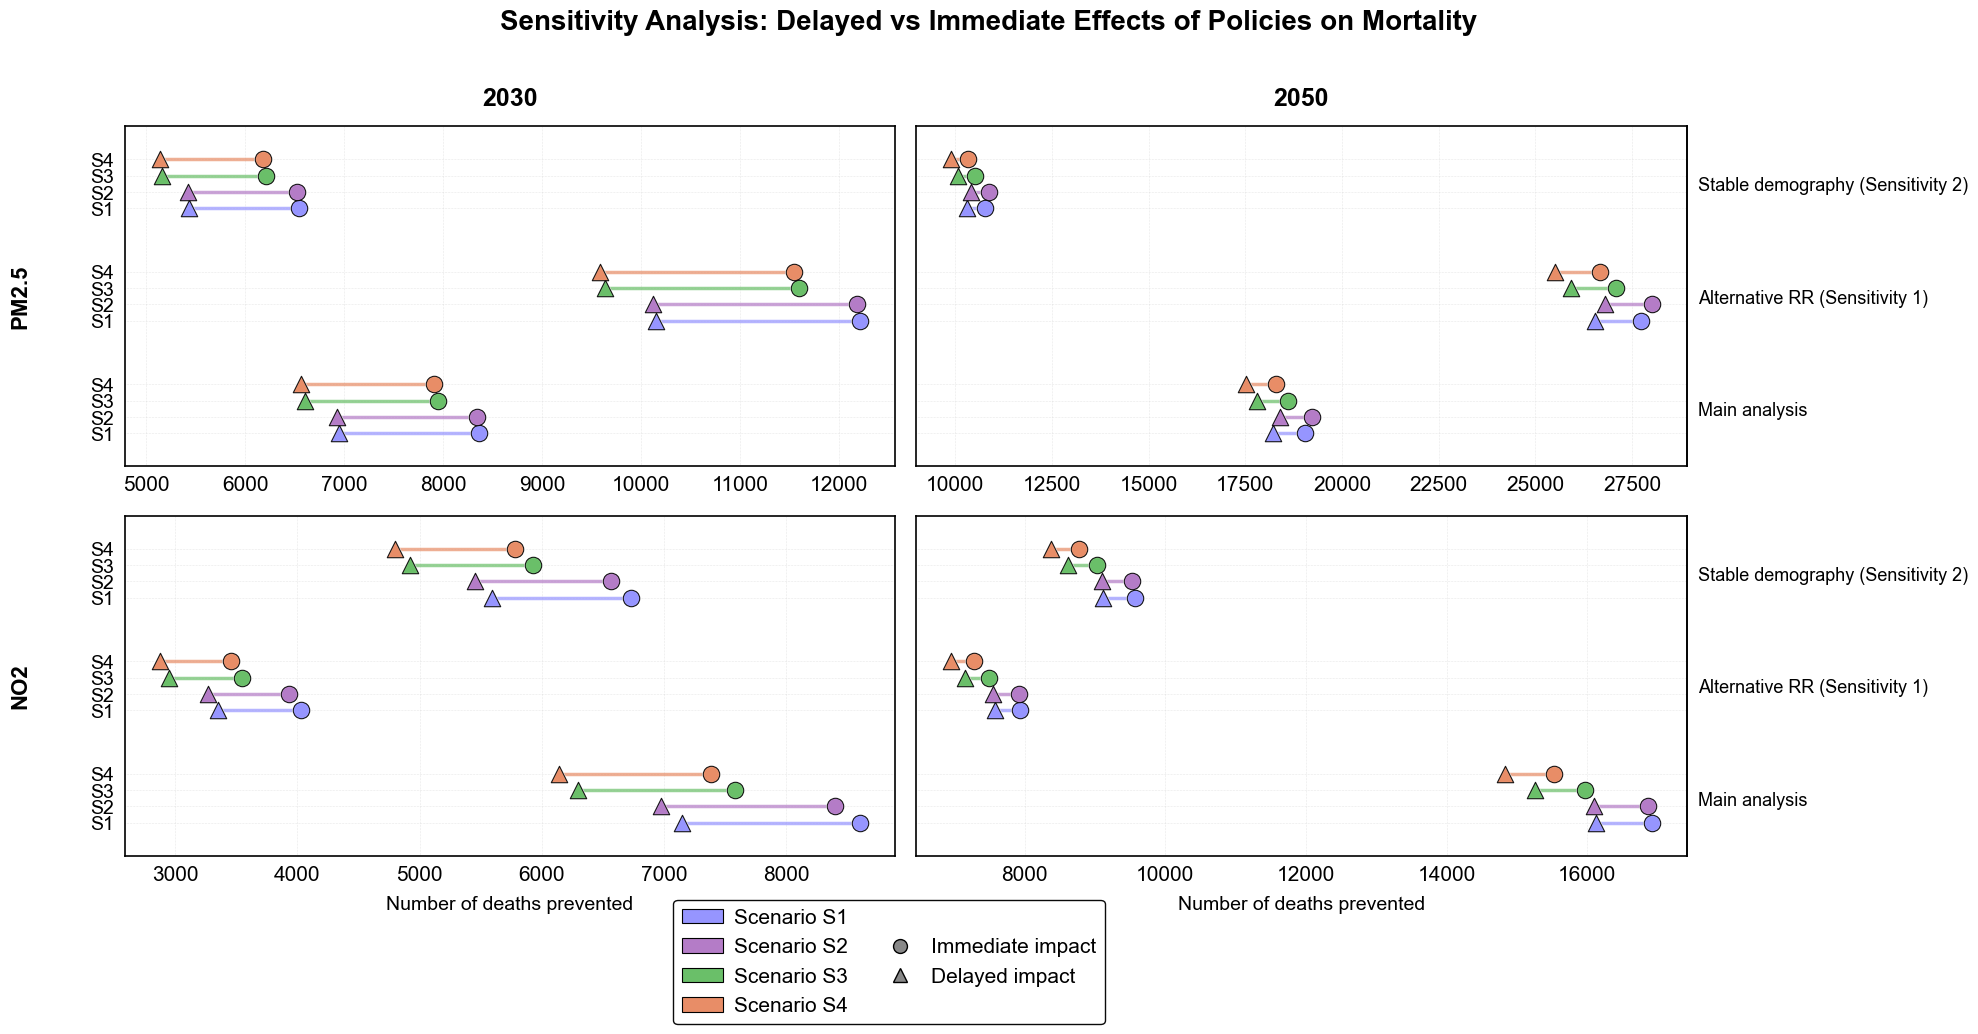

In [50]:
# PLOT delayed vs immediate effects of policies as forest plot
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle
import matplotlib.patches as mpatches

# ---------------- helpers for forest plot----------------
num_re = re.compile(r"[-+]?\d[\d,]*\.?\d*")


def parse_triplet(triplet_str):
    if pd.isna(triplet_str) or not isinstance(triplet_str, str):
        return (np.nan, np.nan, np.nan)
    m = re.match(r"([\d,.]+)\s*\[([\d,.]+)-([\d,.]+)\]", triplet_str.replace(',', ''))
    if m:
        return float(m.group(1)), float(m.group(2)), float(m.group(3))
    try:
        return float(triplet_str.replace(',', '')), np.nan, np.nan
    except:
        return np.nan, np.nan, np.nan


def _sum_median_from_rows(sub_df: pd.DataFrame, colname: str) -> float:
    if colname not in sub_df.columns or sub_df.empty:
        return np.nan
    vals = []
    for v in sub_df[colname].tolist():
        med, _, _ = parse_triplet(v)
        if np.isfinite(med):
            vals.append(med)
    return float(np.sum(vals)) if vals else np.nan


def find_col(df, key):
    matches = [c for c in df.columns if key.lower() in c.lower()]
    return matches[0] if matches else None


# Enhanced styling
BASE_FONTSIZE = 14
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica"],
    "font.size": BASE_FONTSIZE,
    "axes.titlesize": BASE_FONTSIZE + 2,
    "axes.labelsize": BASE_FONTSIZE + 2,
    "xtick.labelsize": BASE_FONTSIZE + 1,
    "ytick.labelsize": BASE_FONTSIZE + 1,
    "legend.fontsize": BASE_FONTSIZE + 1,
    "axes.linewidth": 1.2,
    "grid.linewidth": 0.4,
    "lines.linewidth": 0.5,
    "axes.edgecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "text.color": "black",
})

# Load data
in_file = os.path.join("data", "2-output-data", "economic_summary_morbidity_sensitivity.csv")
df = pd.read_csv(in_file, dtype=str)

scenario_col = find_col(df, "scenario")
year_col = find_col(df, "year")
pollutant_col = find_col(df, "pollutant")
lag_col = find_col(df, "lag")
disease_col = find_col(df, "disease")
deaths_col = find_col(df, "Deaths Avoided")

# Scenarios
scenarios = ["s1", "s2", "s3", "s4"]
scenario_colors = {"s1": "#9695FF", "s2": "#B47CC7", "s3": "#6ABF69", "s4": "#E88D67"}
colors = {s: scenario_colors[s] for s in scenarios}

# Plotting setup
pollutants = list(df[pollutant_col].dropna().astype(str).unique())
years = [2030, 2050]

# SENSITIVITY ASSUMPTIONS - Only mortality-related
base_assumptions = [
    ("Main analysis", "All-cause mortality (main)"),
    ("Alternative RR (Sensitivity 1)", "All-cause mortality (sensitivity 1)"),
    ("Stable demography (Sensitivity 2)", "All-cause mortality (sensitivity 2)"),
]

# Build y-axis data
y_axis_data = []
y_axis_labels = []

for assumption_label, disease_match in base_assumptions:
    for sc in scenarios:
        y_axis_data.append({
            "short_label": f"{sc.upper()}",
            "disease_match": disease_match,
            "scenario": sc,
            "assumption_label": assumption_label,
        })
        y_axis_labels.append(f"{sc.upper()}")

# Calculate y positions with visual grouping
spacing = 0.35
group_spacing = 1.0
y_positions = []
current_y = 0.0
prev_assumption = None

for item in y_axis_data:
    current_assumption = item["assumption_label"]

    if prev_assumption is not None and current_assumption != prev_assumption:
        current_y += group_spacing

    y_positions.append(current_y)
    current_y += spacing
    prev_assumption = current_assumption

y_min = -spacing * 2
y_max = y_positions[-1] + spacing * 2

# Calculate group centers for right-side labels
group_centers = []
group_labels_unique = []
prev_assumption = None
group_start_idx = 0

for i, item in enumerate(y_axis_data):
    current_assumption = item["assumption_label"]
    if prev_assumption is not None and current_assumption != prev_assumption:
        center_y = float(np.mean(y_positions[group_start_idx:i]))
        group_centers.append(center_y)
        group_labels_unique.append(prev_assumption)
        group_start_idx = i
    prev_assumption = current_assumption

if prev_assumption is not None:
    center_y = float(np.mean(y_positions[group_start_idx:]))
    group_centers.append(center_y)
    group_labels_unique.append(prev_assumption)

# Lag types with clearer labels
lag_types = [
    ("no_lag", "Immediate impact", "o", 140),
    ("cessation_lag", "Delayed impact", "^", 140),
]
lag_markers = {k: (m, s) for k, _, m, s in lag_types}

# Create figure with better proportions
n_pollutants = len(pollutants)
n_years = len(years)
fig_width = 20
fig_height = max(10, n_pollutants * 5)

fig, axes = plt.subplots(
    nrows=n_pollutants,
    ncols=n_years,
    figsize=(fig_width, fig_height),
    sharex=False,
    sharey=True,
)

# Handle different subplot configurations
if n_pollutants == 1 and n_years == 1:
    axes = np.array([[axes]])
elif n_pollutants == 1:
    axes = np.array([axes])
elif n_years == 1:
    axes = np.array([[ax] for ax in axes])

# Plot data
for pol_idx, pol in enumerate(pollutants):
    df_pol = df[df[pollutant_col] == pol].copy()

    if disease_col:
        dis_norm = df_pol[disease_col].astype(str).str.upper().str.strip()
        keep_dis = {item["disease_match"].upper().strip() for item in y_axis_data if item["disease_match"]}
        df_mort = df_pol[dis_norm.isin(keep_dis)].copy()
    else:
        df_mort = df_pol.copy()

    for col_idx, year in enumerate(years):
        ax = axes[pol_idx, col_idx]
        df_year_mort = df_mort[pd.to_numeric(df_mort[year_col], errors="coerce") == year]

        # Plot dumbbells
        for j, item in enumerate(y_axis_data):
            y = float(y_positions[j])
            disease_match = item["disease_match"]
            sc = item["scenario"]

            vals_by_lag = {}
            for lag_value, _, _, _ in lag_types:
                if disease_col:
                    sub = df_year_mort[
                        (df_year_mort[scenario_col] == sc)
                        & (df_year_mort[lag_col] == lag_value)
                        & (df_year_mort[disease_col].astype(str).str.strip() == disease_match)
                        ]
                else:
                    sub = df_year_mort[
                        (df_year_mort[scenario_col] == sc)
                        & (df_year_mort[lag_col] == lag_value)
                        ]

                if sub.empty:
                    vals_by_lag[lag_value] = np.nan
                    continue

                base_value = _sum_median_from_rows(sub, deaths_col)
                vals_by_lag[lag_value] = base_value

            x_no = float(vals_by_lag.get("no_lag", np.nan))
            x_lag = float(vals_by_lag.get("cessation_lag", np.nan))

            # Draw connecting line
            if np.isfinite(x_no) and np.isfinite(x_lag):
                ax.plot(
                    [x_no, x_lag],
                    [y, y],
                    color=colors[sc],
                    linewidth=2.5,
                    alpha=0.7,
                    zorder=3,
                    solid_capstyle="round",
                )

            # Draw markers
            if np.isfinite(x_no):
                marker, size = lag_markers["no_lag"]
                ax.scatter(
                    x_no, y,
                    color=colors[sc],
                    s=size,
                    marker=marker,
                    edgecolor="white",
                    linewidth=1.5,
                    zorder=4,
                )
                ax.scatter(
                    x_no, y,
                    color=colors[sc],
                    s=size,
                    marker=marker,
                    edgecolor="black",
                    linewidth=0.8,
                    zorder=5,
                    alpha=0.9,
                )

            if np.isfinite(x_lag):
                marker, size = lag_markers["cessation_lag"]
                ax.scatter(
                    x_lag, y,
                    color=colors[sc],
                    s=size,
                    marker=marker,
                    edgecolor="white",
                    linewidth=1.5,
                    zorder=4,
                )
                ax.scatter(
                    x_lag, y,
                    color=colors[sc],
                    s=size,
                    marker=marker,
                    edgecolor="black",
                    linewidth=0.8,
                    zorder=5,
                    alpha=0.9,
                )

        # Axis formatting
        ax.set_ylim(y_min, y_max)
        ax.set_yticks(y_positions)

        # Y-axis labels only on leftmost column
        if col_idx == 0:
            ax.set_yticklabels(y_axis_labels, fontsize=BASE_FONTSIZE)
            ax.tick_params(axis="y", length=4, width=1.2, colors="black")
        else:
            ax.tick_params(axis="y", labelleft=False, length=0, colors="black")

        ax.tick_params(axis="x", colors="black", width=1.2)

        # Title only on top row
        if pol_idx == 0:
            ax.set_title(f"{year}", fontsize=BASE_FONTSIZE + 4, weight="bold", pad=15, color="black")

        # Y-label on leftmost column
        if col_idx == 0:
            pol_clean = str(pol).replace("_", " ").strip()
            pol_upper = pol_clean.upper()
            pol_upper = pol_upper.replace("PM25", "PM2.5").replace("PM 25", "PM2.5")
            ax.set_ylabel(
                f"{pol_upper}\n\n",
                fontsize=BASE_FONTSIZE + 2,
                weight="semibold",
                labelpad=10,
                color="black",
            )

        # X-axis label on bottom row
        if pol_idx == n_pollutants - 1:
            ax.set_xlabel("Number of deaths prevented", fontsize=BASE_FONTSIZE, labelpad=8, color="black")

        # Grid
        ax.grid(axis="x", linestyle=":", color="#D0D0D0", linewidth=0.4, alpha=0.9, zorder=1)
        ax.grid(axis="y", linestyle=":", color="#D0D0D0", linewidth=0.4, alpha=0.9, zorder=1)

        # Spines - show all borders (black)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.2)
            spine.set_color("black")

        # Add group labels on rightmost column
        if col_idx == n_years - 1:
            ax2 = ax.twinx()
            ax2.set_ylim(ax.get_ylim())
            ax2.set_yticks(group_centers)
            ax2.set_yticklabels(
                group_labels_unique,
                fontsize=BASE_FONTSIZE - 1,
                color="black",
            )
            ax2.tick_params(axis="y", length=0, pad=8, colors="black")
            ax2.spines["right"].set_visible(True)
            ax2.spines["right"].set_linewidth(1.2)
            ax2.spines["right"].set_color("black")
            ax2.spines["top"].set_visible(False)
            ax2.spines["bottom"].set_visible(False)
            ax2.spines["left"].set_visible(False)
            ax2.grid(axis='y', visible=False)

# Simplified legend
legend_elements = []

# Scenarios
for sc in scenarios:
    legend_elements.append(
        Patch(facecolor=colors[sc], edgecolor="black", linewidth=0.8, label=f"Scenario {sc.upper()}"))
# Spacer
legend_elements.append(mpatches.Patch(color="none", label="  "))

# Lag types
for lag_value, label, marker, size in lag_types:
    legend_elements.append(
        plt.Line2D(
            [0], [0],
            marker=marker,
            color="w",
            label=label,
            markerfacecolor="#888888",
            markeredgecolor="black",
            markersize=10,
            linewidth=0,
        )
    )

# Position legend
fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=2,
    frameon=True,
    fontsize=BASE_FONTSIZE + 1,
    bbox_to_anchor=(0.45, -0.03),
    edgecolor="black",
    framealpha=0.96,
    columnspacing=1.5,
    handletextpad=0.5,
)

# Main title
fig.suptitle(
    "Sensitivity Analysis: Delayed vs Immediate Effects of Policies on Mortality",
    fontsize=BASE_FONTSIZE + 6,
    weight="bold",
    y=0.995,
    color="black",
)

# Ensure figure border is black
fig.patch.set_facecolor("white")

# Adjust layout
plt.tight_layout(rect=[0, 0.07, 1, 0.985])

# Save
save_path = "data/2-output-data/plots/policy_deaths_mortality_sensitivity.png"
fig.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white", edgecolor="black")
print(f"Saved: {save_path}")
plt.show()


In [ ]:
# PLOT delayed vs immediate effects of policies as forest plot for DALY = YLL + YLD
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle
import matplotlib.patches as mpatches

# Enhanced styling
BASE_FONTSIZE = 14
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica"],
    "font.size": BASE_FONTSIZE,
    "axes.titlesize": BASE_FONTSIZE + 2,
    "axes.labelsize": BASE_FONTSIZE + 1,
    "xtick.labelsize": BASE_FONTSIZE + 1,
    "ytick.labelsize": BASE_FONTSIZE + 1,
    "legend.fontsize": BASE_FONTSIZE + 1,
    "axes.linewidth": 1.2,
    "grid.linewidth": 0.4,
    "lines.linewidth": 0.5,
    "axes.edgecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "text.color": "black",
})

# Load data
in_file = os.path.join("data", "2-output-data", "economic_summary_morbidity_sensitivity.csv")
df = pd.read_csv(in_file, dtype=str)

scenario_col = find_col(df, "scenario")
year_col = find_col(df, "year")
pollutant_col = find_col(df, "pollutant")
lag_col = find_col(df, "lag")
disease_col = find_col(df, "disease")
yll_col = find_col(df, "YLL Avoided")
yld_col = find_col(df, "YLD Avoided")

# Scenarios
scenarios = ["s1", "s2", "s3", "s4"]
scenario_colors = {"s1": "#9695FF", "s2": "#B47CC7", "s3": "#6ABF69", "s4": "#E88D67"}
colors = {s: scenario_colors[s] for s in scenarios}

# Plotting setup
pollutants = list(df[pollutant_col].dropna().astype(str).unique())
years = [2030, 2050]

# SENSITIVITY ASSUMPTIONS
base_assumptions = [
    ("Main analysis", "All-cause mortality (main)"),
    ("Alternative RR (Sensitivity 1)", "All-cause mortality (sensitivity 1)"),
    ("Stable demography (Sensitivity 2)", "All-cause mortality (sensitivity 2)"),
]
mortality_diseases = {d.upper().strip() for _, d in base_assumptions}

# Build y-axis data
y_axis_data = []
y_axis_labels = []

for assumption_label, disease_match in base_assumptions:
    for sc in scenarios:
        y_axis_data.append({
            "short_label": f"{sc.upper()}",
            "disease_match": disease_match,
            "scenario": sc,
            "assumption_label": assumption_label,
        })
        y_axis_labels.append(f"{sc.upper()}")

# Calculate y positions with visual grouping
spacing = 0.35
group_spacing = 1.0
y_positions = []
current_y = 0.0
prev_assumption = None

for item in y_axis_data:
    current_assumption = item["assumption_label"]

    if prev_assumption is not None and current_assumption != prev_assumption:
        current_y += group_spacing

    y_positions.append(current_y)
    current_y += spacing
    prev_assumption = current_assumption

y_min = -spacing * 2
y_max = y_positions[-1] + spacing * 2

# Calculate group centers for right-side labels
group_centers = []
group_labels_unique = []
prev_assumption = None
group_start_idx = 0

for i, item in enumerate(y_axis_data):
    current_assumption = item["assumption_label"]
    if prev_assumption is not None and current_assumption != prev_assumption:
        center_y = float(np.mean(y_positions[group_start_idx:i]))
        group_centers.append(center_y)
        group_labels_unique.append(prev_assumption)
        group_start_idx = i
    prev_assumption = current_assumption

if prev_assumption is not None:
    center_y = float(np.mean(y_positions[group_start_idx:]))
    group_centers.append(center_y)
    group_labels_unique.append(prev_assumption)

# Lag types with clearer labels
lag_types = [
    ("no_lag", "Immediate impact", "o", 140),
    ("cessation_lag", "Delayed impact", "^", 140),
]
lag_markers = {k: (m, s) for k, _, m, s in lag_types}

# Create figure with better proportions
n_pollutants = len(pollutants)
n_years = len(years)
fig_width = 20
fig_height = max(10, n_pollutants * 5)

fig, axes = plt.subplots(
    nrows=n_pollutants,
    ncols=n_years,
    figsize=(fig_width, fig_height),
    sharex=False,
    sharey=True,
)

# Handle different subplot configurations
if n_pollutants == 1 and n_years == 1:
    axes = np.array([[axes]])
elif n_pollutants == 1:
    axes = np.array([axes])
elif n_years == 1:
    axes = np.array([[ax] for ax in axes])

# Plot data
for pol_idx, pol in enumerate(pollutants):
    df_pol = df[df[pollutant_col] == pol].copy()

    for col_idx, year in enumerate(years):
        ax = axes[pol_idx, col_idx]
        df_year = df_pol[pd.to_numeric(df_pol[year_col], errors="coerce") == year].copy()

        # Plot dumbbells
        for j, item in enumerate(y_axis_data):
            y = float(y_positions[j])
            disease_match = item["disease_match"]
            sc = item["scenario"]

            vals_by_lag = {}
            for lag_value, _, _, _ in lag_types:
                sub_all = df_year[
                    (df_year[scenario_col] == sc)
                    & (df_year[lag_col] == lag_value)
                    ].copy()

                if sub_all.empty:
                    vals_by_lag[lag_value] = np.nan
                    continue

                disease_norm = sub_all[disease_col].astype(str).str.upper().str.strip()

                sub_yll = sub_all[disease_norm == disease_match.upper().strip()]
                sub_yld = sub_all[~disease_norm.isin(mortality_diseases)]

                yll_value = _sum_median_from_rows(sub_yll, yll_col)
                yld_value = _sum_median_from_rows(sub_yld, yld_col)

                total_daly = 0.0
                has_value = False
                if np.isfinite(yll_value):
                    total_daly += yll_value
                    has_value = True
                if np.isfinite(yld_value):
                    total_daly += yld_value
                    has_value = True

                vals_by_lag[lag_value] = float(total_daly) if has_value else np.nan

            x_no = float(vals_by_lag.get("no_lag", np.nan))
            x_lag = float(vals_by_lag.get("cessation_lag", np.nan))

            # Draw connecting line
            if np.isfinite(x_no) and np.isfinite(x_lag):
                ax.plot(
                    [x_no, x_lag],
                    [y, y],
                    color=colors[sc],
                    linewidth=2.5,
                    alpha=0.6,
                    zorder=3,
                    solid_capstyle="round",
                )

            # Draw markers
            if np.isfinite(x_no):
                marker, size = lag_markers["no_lag"]
                ax.scatter(
                    x_no, y,
                    color=colors[sc],
                    s=size,
                    marker=marker,
                    edgecolor="white",
                    linewidth=1.5,
                    zorder=4,
                )
                ax.scatter(
                    x_no, y,
                    color=colors[sc],
                    s=size,
                    marker=marker,
                    edgecolor="black",
                    linewidth=0.8,
                    zorder=5,
                    alpha=0.9,
                )

            if np.isfinite(x_lag):
                marker, size = lag_markers["cessation_lag"]
                ax.scatter(
                    x_lag, y,
                    color=colors[sc],
                    s=size,
                    marker=marker,
                    edgecolor="white",
                    linewidth=1.5,
                    zorder=4,
                )
                ax.scatter(
                    x_lag, y,
                    color=colors[sc],
                    s=size,
                    marker=marker,
                    edgecolor="black",
                    linewidth=0.8,
                    zorder=5,
                    alpha=0.9,
                )

        # Axis formatting
        ax.set_ylim(y_min, y_max)
        ax.set_yticks(y_positions)

        # Y-axis labels only on leftmost column
        if col_idx == 0:
            ax.set_yticklabels(y_axis_labels, fontsize=BASE_FONTSIZE)
            ax.tick_params(axis="y", length=4, width=1.2, colors="black")
        else:
            ax.tick_params(axis="y", labelleft=False, length=0, colors="black")

        ax.tick_params(axis="x", colors="black", width=1.2)

        # Title only on top row
        if pol_idx == 0:
            ax.set_title(f"{year}", fontsize=BASE_FONTSIZE + 4, weight="bold", pad=15, color="black")

        # Y-label on leftmost column
        if col_idx == 0:
            pol_clean = str(pol).replace("_", " ").strip()
            pol_upper = pol_clean.upper()
            pol_upper = pol_upper.replace("PM25", "PM2.5").replace("PM 25", "PM2.5")
            ax.set_ylabel(
                f"{pol_upper}\n\n",
                fontsize=BASE_FONTSIZE + 2,
                weight="semibold",
                labelpad=10,
                color="black",
            )

        # X-axis label on bottom row
        if pol_idx == n_pollutants - 1:
            ax.set_xlabel("DALYs averted (YLG + YLD)", fontsize=BASE_FONTSIZE, labelpad=8, color="black")

        # Grid
        ax.grid(axis="x", linestyle="-", color="#D0D0D0", linewidth=0.4, alpha=0.9, zorder=1)
        ax.grid(axis="y", linestyle="-", color="#D0D0D0", linewidth=0.4, alpha=0.9, zorder=1)

        # Spines - show all borders (black)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.2)
            spine.set_color("black")

        # Add group labels on rightmost column
        if col_idx == n_years - 1:
            ax2 = ax.twinx()
            ax2.set_ylim(ax.get_ylim())
            ax2.set_yticks(group_centers)
            ax2.set_yticklabels(
                group_labels_unique,
                fontsize=BASE_FONTSIZE + 1,
                color="black",
            )
            ax2.tick_params(axis="y", length=0, pad=8, colors="black")
            ax2.spines["right"].set_visible(True)
            ax2.grid(axis='y', visible=False)
            ax2.spines["right"].set_color("black")
            ax2.spines["top"].set_visible(False)
            ax2.spines["bottom"].set_visible(False)
            ax2.spines["left"].set_visible(False)

# Simplified legend
legend_elements = []

# Scenarios
for sc in scenarios:
    legend_elements.append(
        Patch(facecolor=colors[sc], edgecolor="black", linewidth=0.8, label=f"Scenario {sc.upper()}"))
# Spacer
legend_elements.append(mpatches.Patch(color="none", label="  "))

# Lag types
for lag_value, label, marker, size in lag_types:
    legend_elements.append(
        plt.Line2D(
            [0], [0],
            marker=marker,
            color="w",
            label=label,
            markerfacecolor="#888888",
            markeredgecolor="black",
            markersize=10,
            linewidth=0,
        )
    )

# Position legend
fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=2,
    frameon=True,
    fontsize=BASE_FONTSIZE + 1,
    bbox_to_anchor=(0.45, -0.03),
    edgecolor="black",
    framealpha=0.96,
    columnspacing=1.5,
    handletextpad=0.5,
)

# Main title
fig.suptitle(
    "Sensitivity Analysis: Delayed vs Immediate Effects of Policies on DALYs",
    fontsize=BASE_FONTSIZE + 6,
    weight="bold",
    y=0.995,
    color="black",
)

# Ensure figure border is black
fig.patch.set_facecolor("white")

# Adjust layout
plt.tight_layout(rect=[0, 0.07, 1, 0.985])

# Save
save_path = "data/2-output-data/plots/policy_daly_sensitivity.png"
fig.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white", edgecolor="black")
print(f"Saved: {save_path}")
plt.show()
